## **Model Evaluation**

#### **Loading Libraries**

In [20]:
import warnings
import pandas as pd 
import numpy as np 
import seaborn as sns  
from sklearn import tree  
import matplotlib.pyplot as plt     
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import  LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.metrics import mean_squared_error, auc, r2_score, roc_curve, accuracy_score, classification_report, roc_auc_score,ConfusionMatrixDisplay, confusion_matrix
warnings.filterwarnings("ignore")

#### **Loading Data**

In [3]:
df = pd.read_csv("f1_strategy_dataset_v4.csv")
df.shape

(101371, 16)

In [4]:
df.dtypes

Driver                        str
LapNumber                   int64
Compound                      str
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
Race                          str
Year                        int64
LapTime_Delta             float64
Cumulative_Degradation    float64
PitStop                     int64
PitNextLap                  int64
RaceProgress              float64
Normalized_TyreLife       float64
Position_Change           float64
dtype: object

#### **Creating our pipeline**

In [7]:
categorical_cols = ['Driver','Compound', 'Race']

numerical_cols = ['LapNumber',  'Stint', 'TyreLife', 'Position',
       'LapTime (s)',  'Year', 'LapTime_Delta',
       'Cumulative_Degradation', 'PitStop',  'RaceProgress',
       'Normalized_TyreLife', 'Position_Change']

In [8]:
preprocessor = ColumnTransformer([
    ('num',StandardScaler(), numerical_cols), 
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
])

# pipeline 
#  Decision Tree
pipeline_dt = Pipeline(
    [
        ('prep', preprocessor), 
        ('clf', tree.DecisionTreeClassifier (class_weight='balanced', max_depth = 15))
    ]
)
#  Logistic regression
pipeline_lr = Pipeline(
    [
        ('prep', preprocessor), 
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
    ]
)

# random forest 
pipeline_rf = Pipeline(
    [
        ('prep', preprocessor), 
        ('clf', RandomForestClassifier(class_weight='balanced',  n_estimators=50, random_state=42))
    ]
)

#### **Splitting using naive approach(80-20)**

In [9]:
X = df.drop(columns = ['PitNextLap']) # features 
y = df['PitNextLap'] # target 
y = pd.DataFrame(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [36]:

def plotROC(y_test, y_prob):
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr) 
    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier (AUC=0.5)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title('ROC Curve – Pitstop Drop-out Prediction', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    

def evaluate(model_name,model, y_test, y_pred, y_prob):
    print(f"{model_name} Classification Report")
    print("================================================")
    print(classification_report(y_test, y_pred))
    print(f"ROC_SCORE: {roc_auc_score(y_test, y_prob)}")
    print(f"Accuracy: {accuracy_score(y_pred=y_pred, y_true=y_test)}")
    plotROC(y_test=y_test, y_prob=y_prob)

    


#### **Model Fit & Evaluation**

- [Plot ROC_AUC curve](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html)

Decision Tree

In [10]:
pipeline_dt.fit(X_train, y_train)
y_pred_dt = pipeline_dt.predict(X_test)
y_prob_dt = pipeline_dt.predict_proba(X_test)[:,1]

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.96      0.87      0.91     15109
           1       0.70      0.90      0.79      5166

    accuracy                           0.88     20275
   macro avg       0.83      0.88      0.85     20275
weighted avg       0.89      0.88      0.88     20275

ROC_SCORE: 0.9251591935612443
Accuracy: 0.8755117139334155


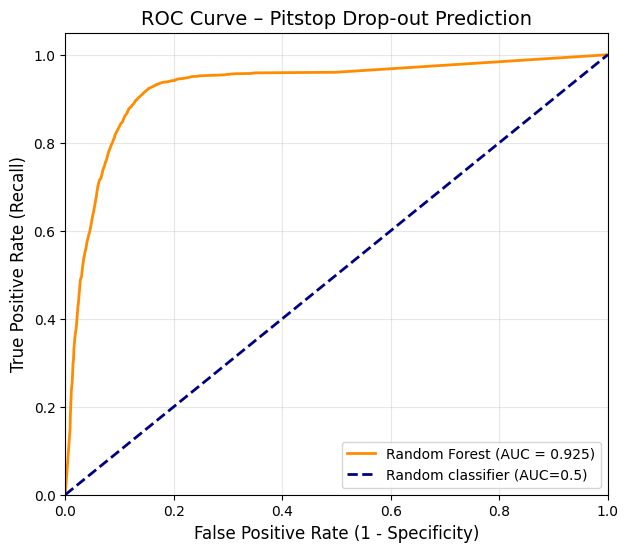

In [38]:
evaluate("Decision Tree", pipeline_dt, y_test=y_test, y_pred=y_pred_dt, y_prob=y_prob_dt)

Logisitic Regression

In [39]:
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:,1]

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.89      0.72      0.80     15109
           1       0.48      0.74      0.58      5166

    accuracy                           0.73     20275
   macro avg       0.69      0.73      0.69     20275
weighted avg       0.79      0.73      0.74     20275

ROC_SCORE: 0.8036219806994455
Accuracy: 0.7279901356350185


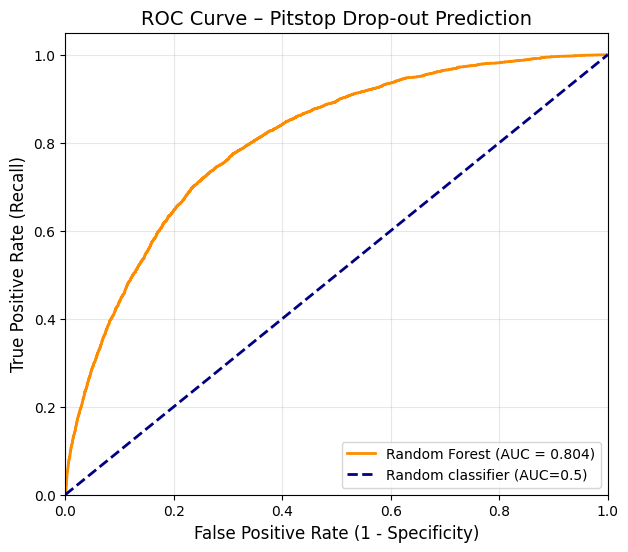

In [40]:
evaluate("Logistic Regression",pipeline_lr, y_test=y_test, y_pred=y_pred_lr, y_prob=y_prob_lr)

Random Forest

In [12]:
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:,1]

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     15109
           1       0.96      0.90      0.93      5166

    accuracy                           0.97     20275
   macro avg       0.97      0.94      0.95     20275
weighted avg       0.97      0.97      0.97     20275

ROC_SCORE: 0.9932643413213064
Accuracy: 0.9659186189889026


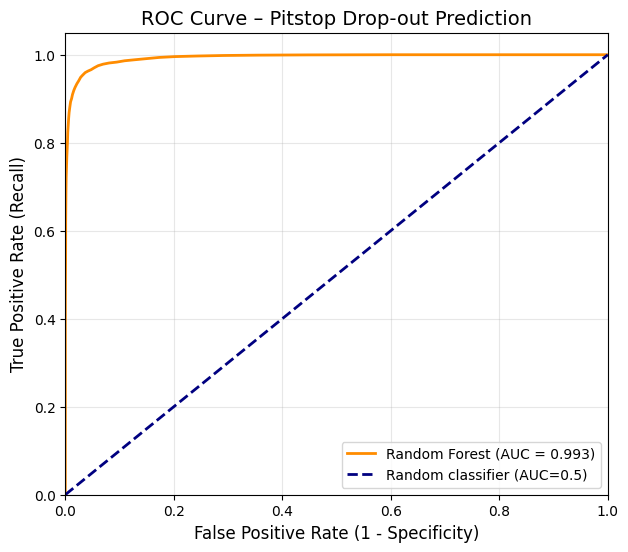

In [41]:
evaluate("Random Forest",pipeline_rf, y_test=y_test, y_pred=y_pred_rf, y_prob=y_prob_rf)

#### **Splitting using k-fold cross-validation**

In [ ]:

def plotROC(y_test, y_prob):
    fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
    roc_auc = auc(fpr, tpr) 
    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier (AUC=0.5)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title('ROC Curve – Pitstop Drop-out Prediction', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    

def evaluate(model_name,model, y_test, y_pred, y_prob):
    print(f"{model_name} Classification Report")
    print("================================================")
    print(classification_report(y_test, y_pred))
    print(f"ROC_SCORE: {roc_auc_score(y_test, y_prob)}")
    print(f"Accuracy: {accuracy_score(y_pred=y_pred, y_true=y_test)}")
    plotROC(y_test=y_test, y_prob=y_prob)

In [44]:
gkf = GroupKFold(n_splits = 5)


lr_scores = cross_val_score(
    pipeline_lr, X, y, cv=gkf, groups=df['Race'],
    scoring=['roc_auc, accuracy, f1,precision,recall'], n_jobs =-1
)


dt_scores = cross_val_score(
    pipeline_dt, X, y, cv=gkf, groups=df['Race'],
    scoring=['roc_auc, accuracy, f1,precision,recall'], n_jobs =-1
)


rf_scores =  cross_val_score(
    pipeline_rf, X, y, cv=gkf, groups=df['Race'],
    scoring=['roc_auc, accuracy, f1,precision,recall'], n_jobs =-1
)


print(f"# k-folds = {gkf},  Logistic Regression AUC {lr_scores.mean() } + or - {(lr_scores.std() )}")
print(f"# k-folds = {gkf},  Decision Trees AUC {dt_scores.mean() } + or - {(dt_scores.std() )}")
print(f"# k-folds = {gkf},  RandomForest AUC {rf_scores.mean() } + or - {(rf_scores.std() )}")


InvalidParameterError: The 'scoring' parameter of cross_val_score must be a str among {'neg_root_mean_squared_error', 'precision_weighted', 'd2_absolute_error_score', 'jaccard_samples', 'balanced_accuracy', 'neg_log_loss', 'neg_root_mean_squared_log_error', 'f1_macro', 'neg_mean_absolute_percentage_error', 'recall_micro', 'adjusted_mutual_info_score', 'neg_mean_squared_log_error', 'jaccard_weighted', 'homogeneity_score', 'f1_weighted', 'neg_mean_gamma_deviance', 'recall_macro', 'roc_auc_ovo', 'f1_micro', 'neg_mean_absolute_error', 'd2_log_loss_score', 'average_precision', 'positive_likelihood_ratio', 'f1', 'precision_samples', 'recall', 'normalized_mutual_info_score', 'completeness_score', 'matthews_corrcoef', 'explained_variance', 'neg_max_error', 'neg_mean_poisson_deviance', 'd2_brier_score', 'accuracy', 'top_k_accuracy', 'recall_weighted', 'mutual_info_score', 'precision', 'neg_brier_score', 'f1_samples', 'precision_micro', 'roc_auc_ovr', 'jaccard', 'recall_samples', 'neg_negative_l